In [ ]:
!pip install pandas
!pip install tensorflow

In [13]:
from google.colab import files

uploaded1 = files.upload()

Saving URL dataset.csv to URL dataset.csv


In [3]:
uploaded2 = files.upload()

Saving malicious_phish.csv to malicious_phish.csv


In [ ]:
uploaded3 = files.upload()

Saving new_data_urls.csv to new_data_urls.csv


In [14]:
import pandas as pd
import io

df = pd.read_csv(io.BytesIO(uploaded1['URL dataset.csv']))

#df = pd.read_csv(io.BytesIO(uploaded2['malicious_phish.csv']))

#df3 = pd.read_csv(io.BytesIO(uploaded3['new_data_urls.csv']))

In [ ]:
df2['type'] = df2['type'].replace({
    'benign': 'legitimate',
    'phishing': 'malicious',
    'malware': 'malicious',
    'defacement': 'malicious'
})

df1['type'] = df1['type'].replace({
    'phishing': 'malicious'
})

df = pd.concat([df1, df2])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score

import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
print(type(df))

def normalize_url(url):
  url = re.sub(r'^https?://', '', url)
  url = re.sub(r'^www\.', '', url)
  return url.strip()

df['url_normalized'] = df['url'].apply(normalize_url)

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['type'])
types = df['type'].unique()
print(types)
df.head()

<class 'pandas.core.frame.DataFrame'>
['legitimate' 'malicious']


,url,type,url_normalized,label_encoded
0,https://www.google.com,legitimate,google.com,0
1,https://www.youtube.com,legitimate,youtube.com,0
2,https://www.facebook.com,legitimate,facebook.com,0
3,https://www.baidu.com,legitimate,baidu.com,0
4,https://www.wikipedia.org,legitimate,wikipedia.org,0


In [ ]:
tokenizer = Tokenizer(char_level=True, oov_token='<OOV>')
tokenizer.fit_on_texts(df['url_normalized'])


In [ ]:
y = df['label_encoded']

sequences = tokenizer.texts_to_sequences(df['url'])
X = pad_sequences(sequences, maxlen=200, padding='post', truncating='post')
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}


In [ ]:
model = Sequential([
    layers.Embedding(len(tokenizer.word_index) + 1, 64),
    layers.SpatialDropout1D(0.1),

    layers.Conv1D(128, 7, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(3),
    layers.Dropout(0.2),

    layers.Conv1D(64, 5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(3),
    layers.Dropout(0.2),

    layers.Conv1D(64, 3, activation='relu', padding='same'),
    layers.GlobalMaxPooling1D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256,
    class_weight=class_weight_dict,  # Handle imbalance
    callbacks=[
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True,
            monitor='val_loss'
        ),
        tf.keras.callbacks.ModelCheckpoint(
            'best_model.keras',
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.5,
            patience=2,
            monitor='val_loss'
        )
    ],
    verbose=1
)

results = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test Precision: {results[2]:.4f}")
print(f"Test Recall: {results[3]:.4f}")
print(f"Test AUC: {results[4]:.4f}")

Epoch 1/20
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9414 - auc: 0.9759 - loss: 0.6357 - precision: 0.8863 - recall: 0.9267
Epoch 1: val_auc improved from -inf to 0.99636, saving model to best_model.keras
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 99s 32ms/step - accuracy: 0.9414 - auc: 0.9759 - loss: 0.6355 - precision: 0.8863 - recall: 0.9267 - val_accuracy: 0.9838 - val_auc: 0.9964 - val_loss: 0.0826 - val_precision: 0.9715 - val_recall: 0.9738 - learning_rate: 0.0010
Epoch 2/20
2409/2410 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9815 - auc: 0.9959 - loss: 0.0952 - precision: 0.9633 - recall: 0.9751
Epoch 2: val_auc improved from 0.99636 to 0.99771, saving model to best_model.keras
2410/2410 ━━━━━━━━━━━━━━━━━━━━ 61s 25ms/step - accuracy: 0.9815 - auc: 0.9959 - loss: 0.0952 - precision: 0.9633 - recall: 0.9751 - val_accuracy: 0.9843 - val_auc: 0.9977 - val_loss: 0.0791 - val_precision: 0.9667 - val_recall: 0.9807 - learning_rate: 0.0010
Epoch 3/20
2409/2410 ━━━━━━━━━━━━━━━━

In [ ]:
import pickle
import json

model.save('malicious_url_detector.keras')

with open("model.pkl", 'wb') as file:
    pickle.dump(model, file)

with open('tokenizer.pkl', 'wb') as file:
    pickle.dump(tokenizer, file)

tokenizer_config = {
    'word_index': tokenizer.word_index,
    'max_length': 200
}

with open('tokenizer_config.json', 'w') as f:
    json.dump(tokenizer_config, f)

In [ ]:
df3['url_normalized'] = df3['url'].apply(normalize_url)

sequences_test = tokenizer.texts_to_sequences(df3['url'])
X_test = pad_sequences(sequences_test, maxlen=200, padding='post', truncating='post')
y_test = df3['status'].values

In [ ]:
import numpy as np

predictions = model.predict(X_test)
correct_benign = 0
correct_malicious = 0
total_benign = 0
total_malicious = 0
for i, (true, pred) in enumerate(zip(y_test, predictions)):
    pred_label = 1 if pred[0] > 0.5 else 0
    if true == 1:
      if pred_label == 1:
        correct_malicious += 1
      total_malicious += 1
    if true == 0:
      if pred_label == 0:
        correct_benign += 1
      total_benign += 1
print(f"benign: {correct_benign}/{total_benign} = {100*correct_benign/total_benign:.2f}")
print(f"malicious: {correct_malicious}/{total_malicious} = {100*correct_malicious/total_malicious:.2f}")

25688/25688 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step
benign: 127395/394982 = 32.25
malicious: 72333/427028 = 16.94


In [ ]:
# Test on obviously different URLs
test_urls = [
    "http://bond.edu.au/",
    "http://research.mater.org.au/",
    "http://www.riotinto.com/",
    "http://www.teck.com/",
    "http://www.psa-peugeot-citroen.com/",
    "http://www.rug.nl/",
    "https://group.renault.com/en/",
    "http://www.shu.ac.uk/",
    "http://uem.mz/index.php/",
    "http://www.guc.edu.eg/",
    "http://www.hjf.org/",
    "https://www.mcnc.org/",
    "http://uncw.edu/",
    "http://www.artannlabs.com/",
    "http://english.kmust.edu.cn/",
    "http://www.rff.org/",
    "http://www.gla.ac.uk/",
    "http://www.uml.edu/",
    "http://www.ericsson.com/ca/en/"
]

print("\n" + "="*70)
print("SANITY CHECK - Testing on new URLs")
print("="*70)

for url in test_urls:
    seq = tokenizer.texts_to_sequences([url])
    padded = pad_sequences(seq, maxlen=200, padding='post', truncating='post')
    pred = model.predict(padded, verbose=0)[0][0]
    label = "MALICIOUS" if pred > 0.5 else "BENIGN"
    print(f"{url:<50} {label:<12} {pred:.4f}")


SANITY CHECK - Testing on new URLs
bond.edu.au/                                       BENIGN       0.0009
research.mater.org.au/                             BENIGN       0.1132
riotinto.com/                                      BENIGN       0.0001
teck.com/                                          BENIGN       0.0002
sa-peugeot-citroen.com/                            BENIGN       0.0004
rug.nl/                                            BENIGN       0.0021
group.renault.com/en/                              BENIGN       0.2975
www.shu.ac.uk/                                     BENIGN       0.4256
uem.mz/index.php/                                  BENIGN       0.0105
guc.edu.eg/                                        BENIGN       0.0034
hjf.org/                                           BENIGN       0.0013
mcnc.org/                                          BENIGN       0.0001
uncw.edu/                                          BENIGN       0.0000
artannlabs.com/                          

URL DATASET ANALYSIS (CONDENSED)

✓ Loaded 651191 URLs
⏳ Extracting features...
✓ Features extracted

✓ Saved: url_analysis_condensed.png

KEY INSIGHTS

🔗 Protocol:
   Benign URLs with HTTP:    7.8%
   Malicious URLs with HTTP: 19.0%
   ⚠️  11.2% difference → Model may learn spurious correlation!

📏 Length:
   Benign average:    57.0 chars
   Malicious average: 42.4 chars
   Difference:        14.6 chars

🛤️  Paths:
   Benign avg path segments:    2.31
   Malicious avg path segments: 1.85
   Benign with paths:    88.9%
   Malicious with paths: 75.0%

🔗 Hyphens:
   Benign average:    1.84
   Malicious average: 0.47

⚠️  Suspicious TLDs:
   Benign:    0.0%
   Malicious: 1.5%

✅ ANALYSIS COMPLETE!

Visualization saved as 'url_analysis_condensed.png'


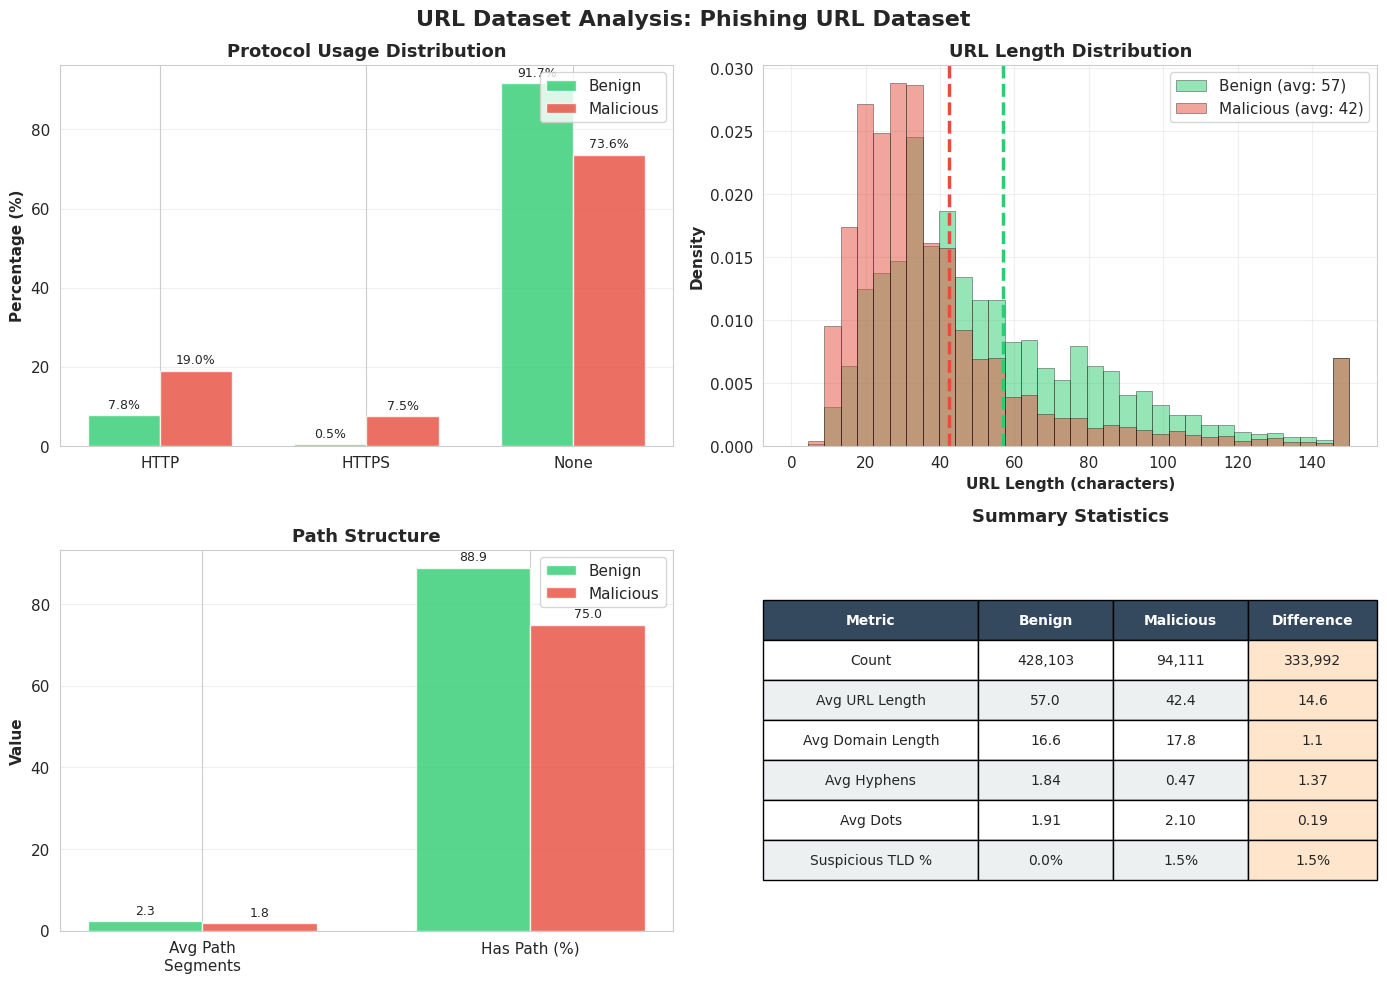

In [18]:
"""
Condensed URL Dataset Visualization
Two comprehensive figures showing all key metrics
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

print("=" * 80)
print("URL DATASET ANALYSIS (CONDENSED)")
print("=" * 80)

# Load and prepare data
df = pd.read_csv('malicious_phish.csv')
print(f"\n✓ Loaded {len(df)} URLs")

# Map to binary
df['type'] = df['type'].replace({
    'legitimate': 'benign',
    'phishing': 'malicious'
})

# Extract features
print("⏳ Extracting features...")

def extract_features(url):
    features = {}
    features['has_http'] = 1 if 'http://' in url else 0
    features['has_https'] = 1 if 'https://' in url else 0
    features['has_protocol'] = features['has_http'] or features['has_https']

    url_normalized = re.sub(r'^https?://', '', url)
    url_normalized = re.sub(r'^www\.', '', url_normalized)

    features['length'] = len(url_normalized)
    parts = url_normalized.split('/', 1)
    features['domain_length'] = len(parts[0])
    features['path'] = parts[1] if len(parts) > 1 else ""
    features['path_segments'] = len([p for p in features['path'].split('/') if p]) if features['path'] else 0
    features['num_hyphens'] = url_normalized.count('-')
    features['num_dots'] = url_normalized.count('.')
    features['suspicious_tld'] = 1 if url_normalized.endswith(('.tk', '.ml', '.ga', '.cf', '.gq', '.xyz')) else 0

    return features

features_df = pd.DataFrame([extract_features(url) for url in df['url']])
df = pd.concat([df, features_df], axis=1)
print("✓ Features extracted")

# Calculate stats
benign = df[df['type'] == 'benign']
malicious = df[df['type'] == 'malicious']

# Colors
color_benign = '#2ecc71'
color_malicious = '#e74c3c'

# ============================================================================
# FIGURE 1: Protocol & Length Analysis
# ============================================================================

fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle('URL Dataset Analysis: Phishing URL Dataset', fontsize=16, fontweight='bold')

# 1.1: Protocol Usage
ax = axes[0, 0]
protocols = ['HTTP', 'HTTPS', 'None']
benign_pct = [
    (benign['has_http'].sum() / len(benign)) * 100,
    (benign['has_https'].sum() / len(benign)) * 100,
    ((1 - benign['has_protocol']).sum() / len(benign)) * 100
]
malicious_pct = [
    (malicious['has_http'].sum() / len(malicious)) * 100,
    (malicious['has_https'].sum() / len(malicious)) * 100,
    ((1 - malicious['has_protocol']).sum() / len(malicious)) * 100
]

x = np.arange(len(protocols))
width = 0.35
bars1 = ax.bar(x - width/2, benign_pct, width, label='Benign', color=color_benign, alpha=0.8)
bars2 = ax.bar(x + width/2, malicious_pct, width, label='Malicious', color=color_malicious, alpha=0.8)

ax.set_ylabel('Percentage (%)', fontweight='bold')
ax.set_title('Protocol Usage Distribution', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(protocols)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 1.2: Length Distribution
ax = axes[0, 1]
max_length = 150
benign_lengths = benign['length'].clip(upper=max_length)
malicious_lengths = malicious['length'].clip(upper=max_length)

bins = np.linspace(0, max_length, 35)
ax.hist(benign_lengths, bins=bins, alpha=0.5, label=f'Benign (avg: {benign["length"].mean():.0f})',
        color=color_benign, density=True, edgecolor='black', linewidth=0.5)
ax.hist(malicious_lengths, bins=bins, alpha=0.5, label=f'Malicious (avg: {malicious["length"].mean():.0f})',
        color=color_malicious, density=True, edgecolor='black', linewidth=0.5)

ax.axvline(benign['length'].mean(), color=color_benign, linestyle='--', linewidth=2.5)
ax.axvline(malicious['length'].mean(), color=color_malicious, linestyle='--', linewidth=2.5)

ax.set_xlabel('URL Length (characters)', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('URL Length Distribution', fontweight='bold', fontsize=13)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

# 1.3: Path Segments
ax = axes[1, 0]
benign_avg_paths = benign['path_segments'].mean()
malicious_avg_paths = malicious['path_segments'].mean()
benign_has_path = (benign['path_segments'] > 0).sum() / len(benign) * 100
malicious_has_path = (malicious['path_segments'] > 0).sum() / len(malicious) * 100

metrics = ['Avg Path\nSegments', 'Has Path (%)']
benign_vals = [benign_avg_paths, benign_has_path]
malicious_vals = [malicious_avg_paths, malicious_has_path]

x = np.arange(len(metrics))
width = 0.35
bars1 = ax.bar(x - width/2, benign_vals, width, label='Benign', color=color_benign, alpha=0.8)
bars2 = ax.bar(x + width/2, malicious_vals, width, label='Malicious', color=color_malicious, alpha=0.8)

ax.set_ylabel('Value', fontweight='bold')
ax.set_title('Path Structure', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# 1.4: Summary Statistics Table
ax = axes[1, 1]
ax.axis('off')

summary_data = [
    ['Metric', 'Benign', 'Malicious', 'Difference'],
    ['Count', f'{len(benign):,}', f'{len(malicious):,}', f'{abs(len(benign)-len(malicious)):,}'],
    ['Avg URL Length', f'{benign["length"].mean():.1f}', f'{malicious["length"].mean():.1f}',
     f'{abs(benign["length"].mean() - malicious["length"].mean()):.1f}'],
    ['Avg Domain Length', f'{benign["domain_length"].mean():.1f}', f'{malicious["domain_length"].mean():.1f}',
     f'{abs(benign["domain_length"].mean() - malicious["domain_length"].mean()):.1f}'],
    ['Avg Hyphens', f'{benign["num_hyphens"].mean():.2f}', f'{malicious["num_hyphens"].mean():.2f}',
     f'{abs(benign["num_hyphens"].mean() - malicious["num_hyphens"].mean()):.2f}'],
    ['Avg Dots', f'{benign["num_dots"].mean():.2f}', f'{malicious["num_dots"].mean():.2f}',
     f'{abs(benign["num_dots"].mean() - malicious["num_dots"].mean()):.2f}'],
    ['Suspicious TLD %', f'{(benign["suspicious_tld"].mean() * 100):.1f}%',
     f'{(malicious["suspicious_tld"].mean() * 100):.1f}%',
     f'{abs((benign["suspicious_tld"].mean() - malicious["suspicious_tld"].mean()) * 100):.1f}%'],
]

# Create table
table = ax.table(cellText=summary_data, cellLoc='center', loc='center',
                colWidths=[0.35, 0.22, 0.22, 0.21])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Style header row
for i in range(4):
    cell = table[(0, i)]
    cell.set_facecolor('#34495e')
    cell.set_text_props(weight='bold', color='white')

# Style data rows with alternating colors
for i in range(1, len(summary_data)):
    for j in range(4):
        cell = table[(i, j)]
        if i % 2 == 0:
            cell.set_facecolor('#ecf0f1')
        else:
            cell.set_facecolor('#ffffff')

        # Highlight difference column
        if j == 3:
            cell.set_facecolor('#ffe5cc')

ax.set_title('Summary Statistics', fontweight='bold', fontsize=13, pad=20)

plt.tight_layout()
plt.savefig('url_analysis_condensed.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: url_analysis_condensed.png")

# ============================================================================
# Print Key Insights
# ============================================================================

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

benign_http = (benign['has_http'].sum() / len(benign)) * 100
malicious_http = (malicious['has_http'].sum() / len(malicious)) * 100

print(f"\n🔗 Protocol:")
print(f"   Benign URLs with HTTP:    {benign_http:.1f}%")
print(f"   Malicious URLs with HTTP: {malicious_http:.1f}%")
if abs(benign_http - malicious_http) > 10:
    print(f"   ⚠️  {abs(benign_http - malicious_http):.1f}% difference → Model may learn spurious correlation!")

print(f"\n📏 Length:")
print(f"   Benign average:    {benign['length'].mean():.1f} chars")
print(f"   Malicious average: {malicious['length'].mean():.1f} chars")
print(f"   Difference:        {abs(benign['length'].mean() - malicious['length'].mean()):.1f} chars")

print(f"\n🛤️  Paths:")
print(f"   Benign avg path segments:    {benign['path_segments'].mean():.2f}")
print(f"   Malicious avg path segments: {malicious['path_segments'].mean():.2f}")
print(f"   Benign with paths:    {(benign['path_segments'] > 0).sum() / len(benign) * 100:.1f}%")
print(f"   Malicious with paths: {(malicious['path_segments'] > 0).sum() / len(malicious) * 100:.1f}%")

print(f"\n🔗 Hyphens:")
print(f"   Benign average:    {benign['num_hyphens'].mean():.2f}")
print(f"   Malicious average: {malicious['num_hyphens'].mean():.2f}")
if malicious['num_hyphens'].mean() > benign['num_hyphens'].mean() * 1.5:
    print(f"   ⚠️  Malicious URLs have {malicious['num_hyphens'].mean() / benign['num_hyphens'].mean():.1f}x more hyphens!")

print(f"\n⚠️  Suspicious TLDs:")
print(f"   Benign:    {(benign['suspicious_tld'].mean() * 100):.1f}%")
print(f"   Malicious: {(malicious['suspicious_tld'].mean() * 100):.1f}%")

print("\n" + "=" * 80)
print("✅ ANALYSIS COMPLETE!")
print("=" * 80)
print("\nVisualization saved as 'url_analysis_condensed.png'")

plt.show()